<a href="https://colab.research.google.com/github/Aiswarya444/Single-Cell-RNAseq-Analysis/blob/main/Single_Cell_RNAseq_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scanpy leidenalg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing instal

In [2]:
import scanpy as sc
import pandas as pd

sc.set_figure_params(dpi=80, facecolor='white')

In [3]:
adata = sc.datasets.pbmc3k()

print(adata)

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)


In [4]:
adata.shape

(2700, 32738)

In [5]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [6]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

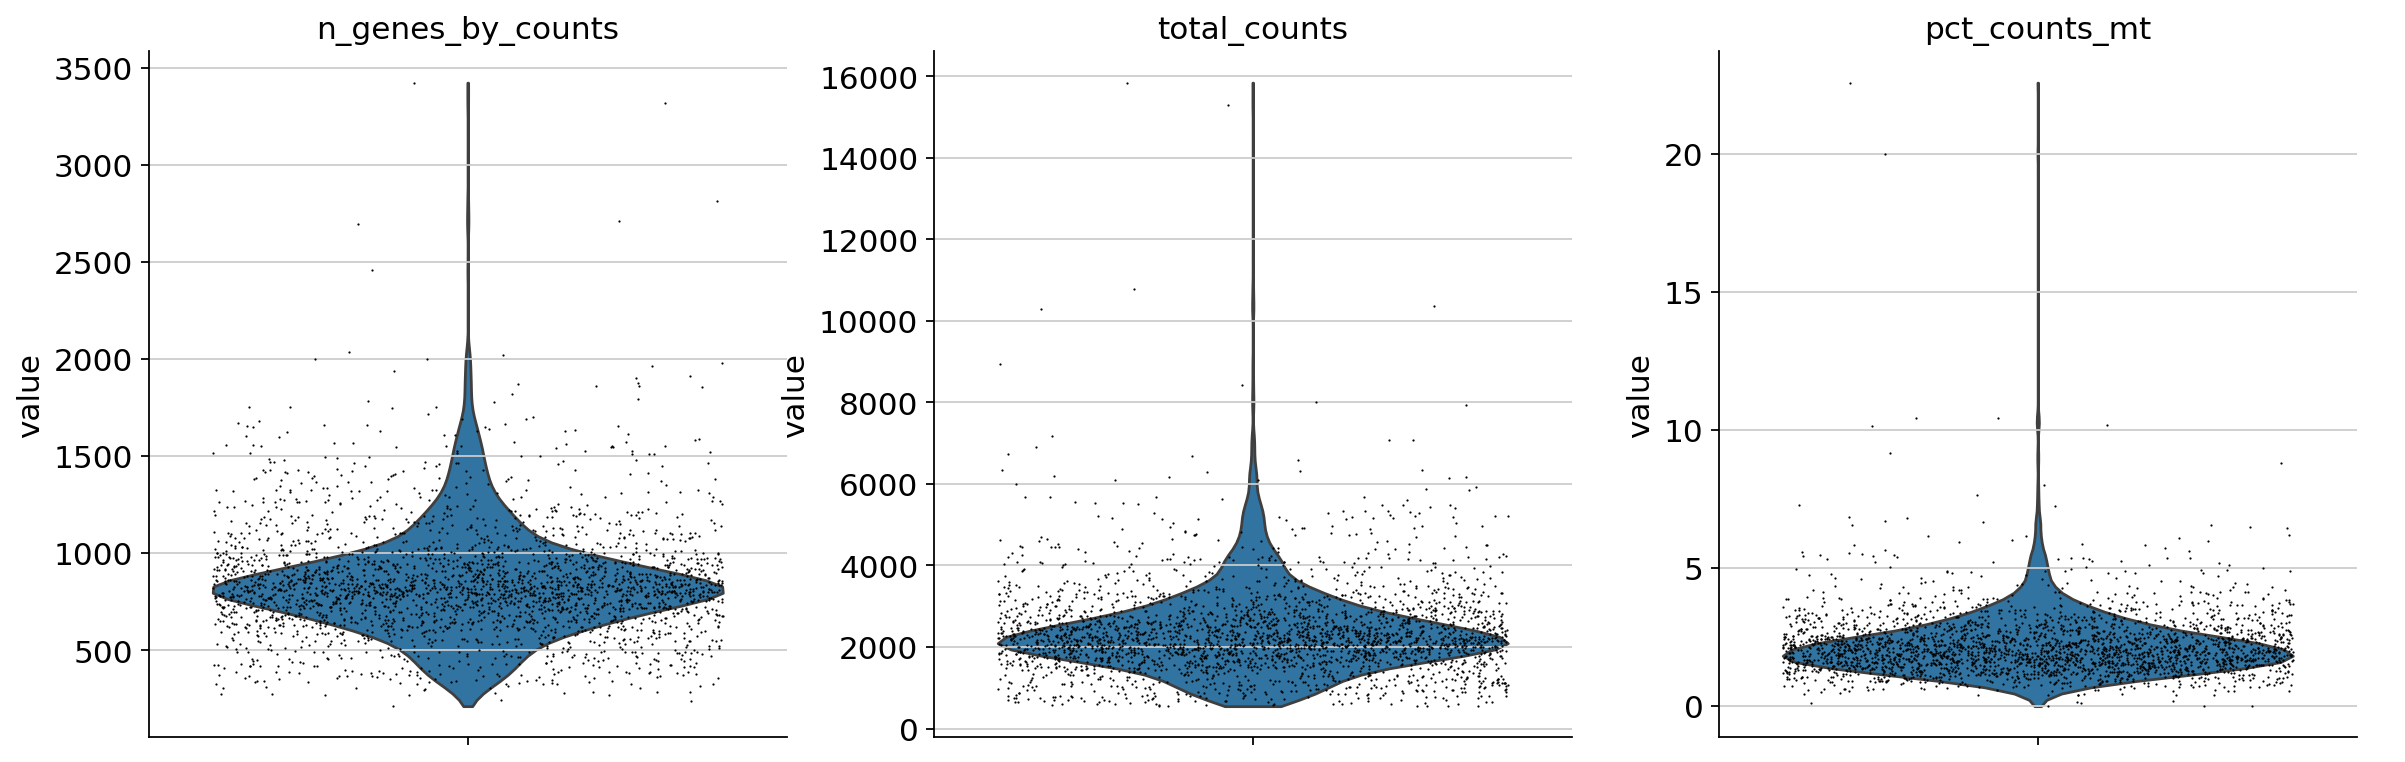

In [7]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

In [8]:
sc.pp.filter_genes(adata, min_cells=3)

In [9]:
sc.pp.filter_cells(adata, min_genes=200)

In [10]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]

In [11]:
adata = adata[adata.obs.pct_counts_mt < 5, :]

In [12]:
print(
    f"After filtering, we have {adata.n_obs} cells "
    f"and {adata.n_vars} genes left."
)

After filtering, we have 2638 cells and 13714 genes left.


In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)

/tmp/ipykernel_1424/3661531845.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


In [14]:
sc.pp.log1p(adata)

In [15]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

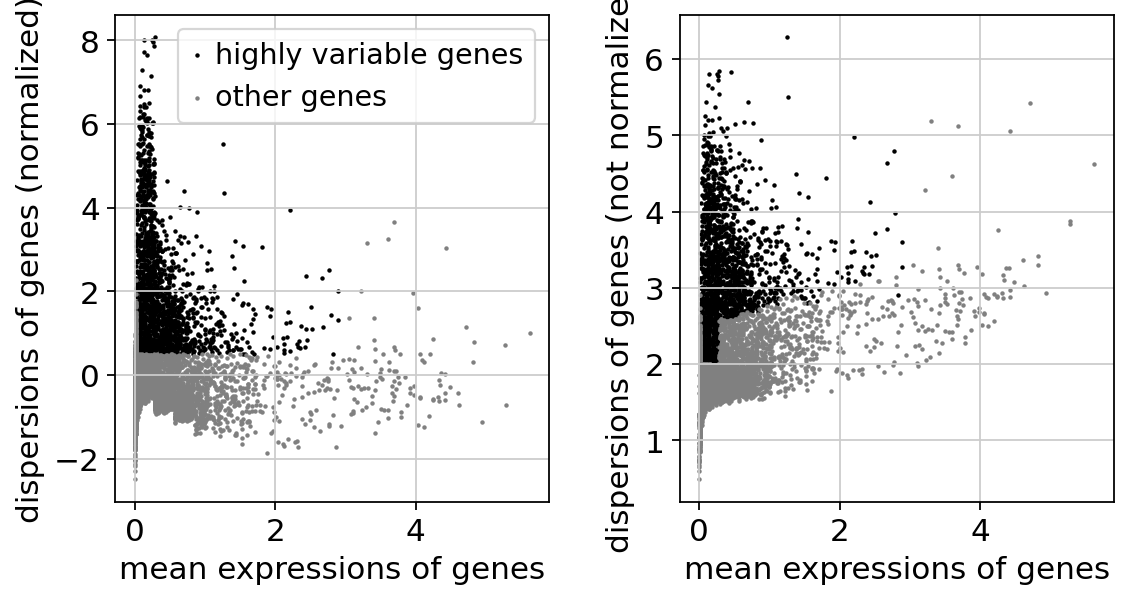

In [16]:
sc.pl.highly_variable_genes(adata)

In [17]:
adata = adata[:, adata.var.highly_variable]

In [18]:
print(adata)

View of AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: None (.X)


In [19]:
sc.pp.scale(adata, max_value=10)

/usr/lib/python3.13/functools.py:934: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [20]:
sc.tl.pca(adata, svd_solver='arpack')

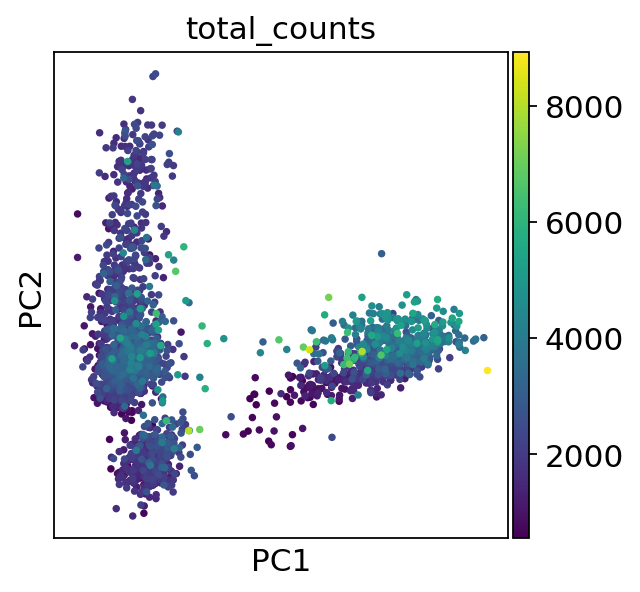

In [22]:
sc.pl.pca(adata, color='total_counts')

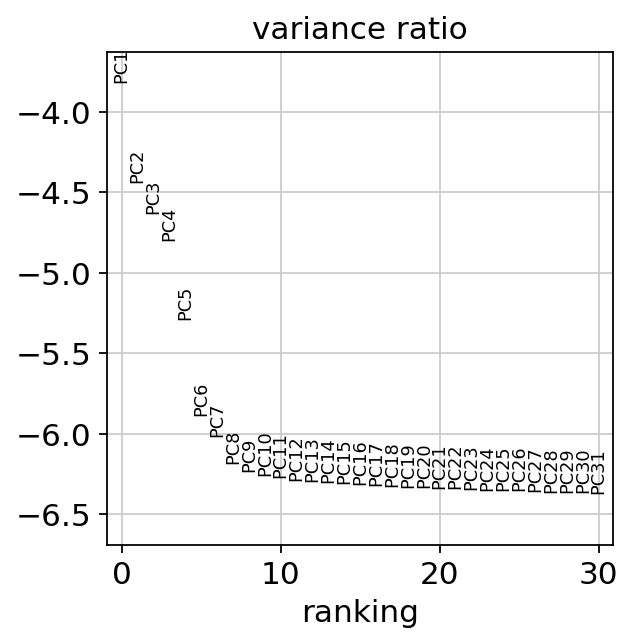

In [23]:
sc.pl.pca_variance_ratio(adata, log=True)

In [24]:
sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=40
)

In [28]:
sc.tl.umap(adata)

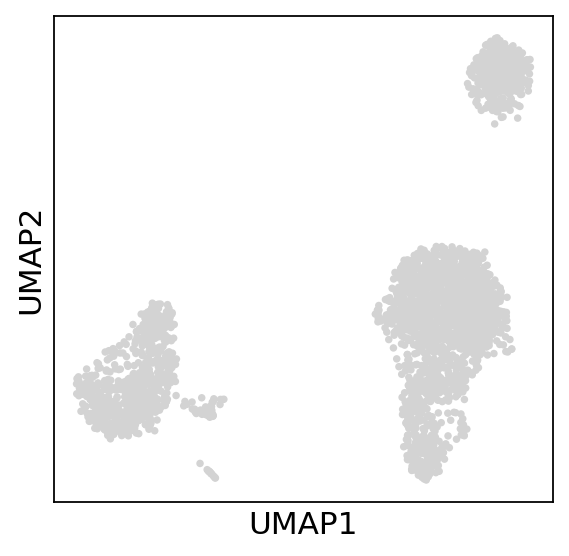

In [29]:
sc.pl.umap(adata)

In [30]:
sc.tl.leiden(adata)

/tmp/ipykernel_1424/3467744858.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


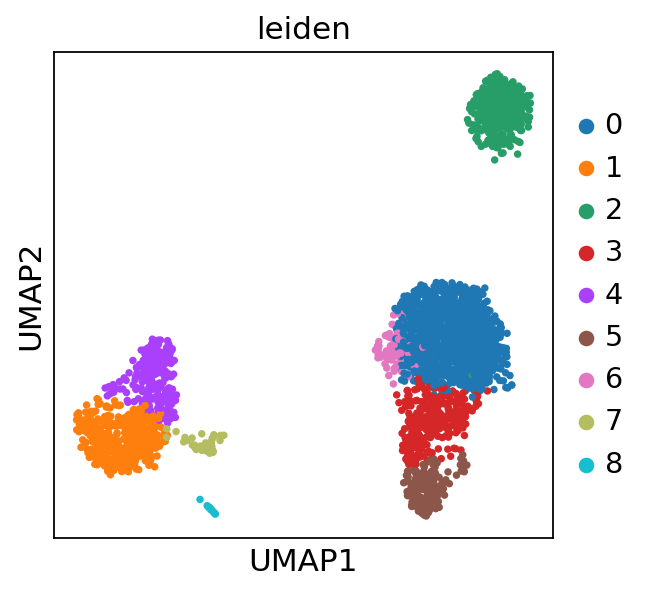

In [31]:
sc.pl.umap(adata, color=['leiden'])